In [ ]:
# Prediction is just estimating any unkown value be it from past, present or future
# Forecasting is also a kind of prediction that we make for the future

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# whatever warnings are there due to methods and code limitations in upcoming
# versions of python will not be shown in the output if we use filterwarnings("ignore")

In [ ]:
df = pd.read_csv("/content/AirPassengers (1).csv")

In [ ]:
df.head()

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [ ]:
df.shape

(144, 2)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Month        144 non-null    object
 1   #Passengers  144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB


In [ ]:
df.isnull().sum()

,0
Month,0
#Passengers,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.rename(columns = {"Month":"month", "#Passengers":"passengers"}, inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   month       144 non-null    object
 1   passengers  144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB


In [ ]:
df['month'] = pd.to_datetime(df['month'])

# converts the month column to datatime from object datatype

In [ ]:
# Data should be ordered by the date

In [ ]:
df.set_index("month", inplace = True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 144 entries, 1949-01-01 to 1960-12-01
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   passengers  144 non-null    int64
dtypes: int64(1)
memory usage: 2.2 KB


In [ ]:
df.head()

,passengers
month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [ ]:
df.dtypes

,0
passengers,int64


In [ ]:
df.tail()

,passengers
month,
1960-08-01,606
1960-09-01,508
1960-10-01,461
1960-11-01,390
1960-12-01,432


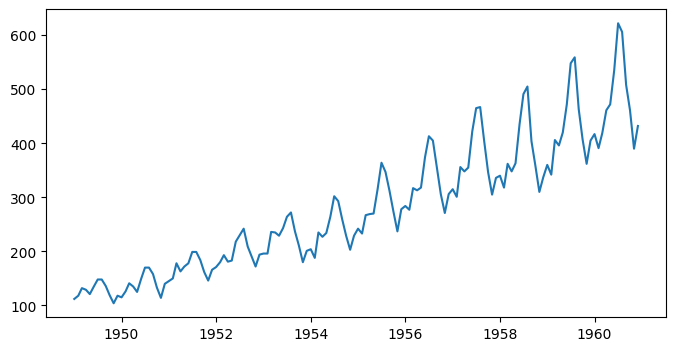

In [ ]:
plt.figure(figsize =(8,4))
plt.plot(df)
plt.show()

Figure(640x480)


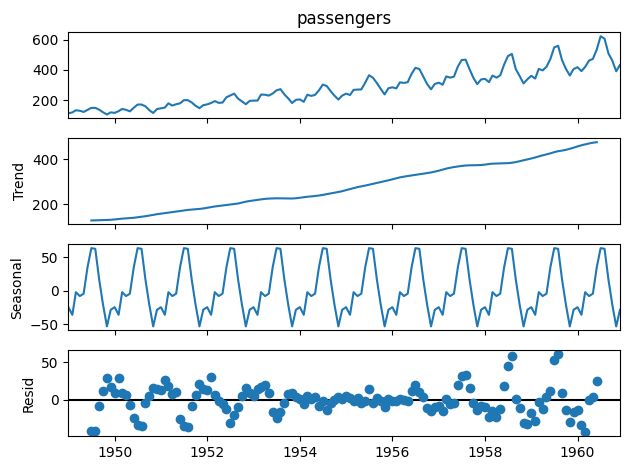

In [ ]:
# Seasonal decompose

from statsmodels.tsa.seasonal import seasonal_decompose

decompose = seasonal_decompose(df['passengers'])
print(decompose.plot())

In [ ]:
from statsmodels.tsa.stattools import adfuller

In [ ]:
result = adfuller(df)
result

(np.float64(0.8153688792060498),
 np.float64(0.991880243437641),
 13,
 130,
 {'1%': np.float64(-3.4816817173418295),
  '5%': np.float64(-2.8840418343195267),
  '10%': np.float64(-2.578770059171598)},
 np.float64(996.692930839019))

In [ ]:
# Null hypothesis: Data is not stationary
# Alternate hypothesis: Data is stationary

In [ ]:
pval =result[1]
pval

np.float64(0.991880243437641)

In [ ]:
if pval>0.05:
  print("Data is not stationary")
else:
  print("Data is stationary")

Data is not stationary


In [ ]:
# exponential growth in data -- log transformations
# square transformation, box-cox transformation

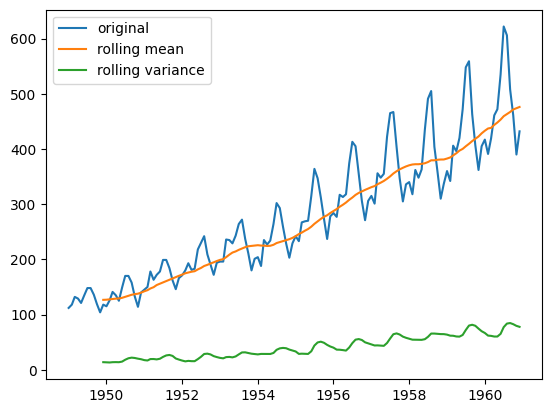

In [ ]:
mean = df.rolling(window = 12).mean()
std = df.rolling(window = 12).std()

plt.plot(df,label = 'original')
plt.plot(mean,label = 'rolling mean')
plt.plot(std, label = "rolling variance")
plt.legend()

In [ ]:
log_df = np.log(df)

In [ ]:
log_df.isnull().sum()

,0
passengers,0


<Axes: xlabel='month'>

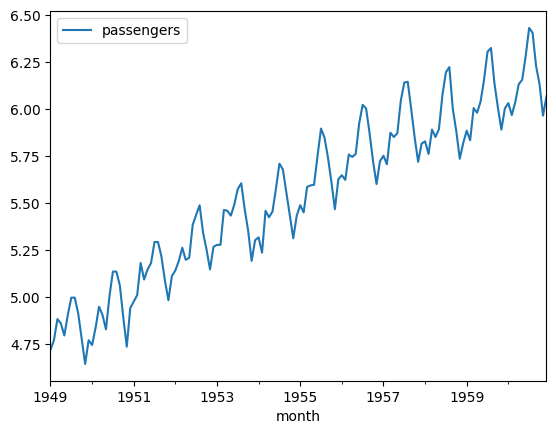

In [ ]:
log_df.plot()

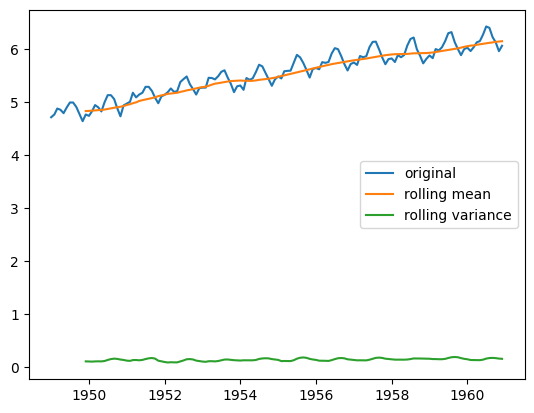

In [ ]:
mean = log_df.rolling(window = 12).mean()
std = log_df.rolling(window = 12).std()

plt.plot(log_df,label = 'original')
plt.plot(mean,label = 'rolling mean')
plt.plot(std, label = "rolling variance")
plt.legend()

In [ ]:
mean.head()

,passengers
month,
1949-01-01,NaN
1949-02-01,NaN
1949-03-01,NaN
1949-04-01,NaN
1949-05-01,NaN


In [ ]:
new_data = log_df - mean
new_data = new_data.dropna()
new_data

,passengers
month,
1949-12-01,-0.065494
1950-01-01,-0.093449
1950-02-01,-0.007566
1950-03-01,0.099416
1950-04-01,0.052142
...,...
1960-08-01,0.282363
1960-09-01,0.098235
1960-10-01,-0.009230


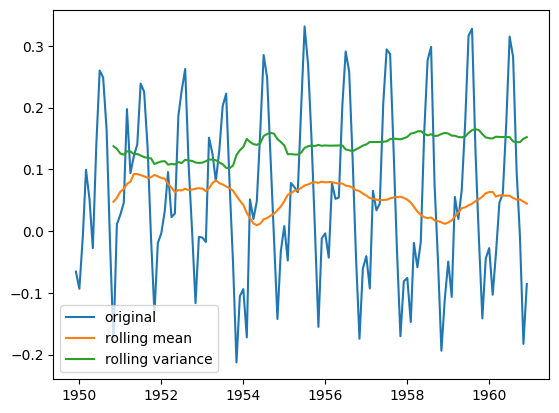

In [ ]:
mean = new_data.rolling(window = 12).mean()
std = new_data.rolling(window = 12).std()

plt.plot(new_data,label = 'original')
plt.plot(mean,label = 'rolling mean')
plt.plot(std, label = "rolling variance")
plt.legend()

In [ ]:
# Arima -- I -- integration -- differentiation for us

In [ ]:
new_data.shape

(133, 1)

In [ ]:
133 * 0.8

106.4

In [ ]:
train = new_data.iloc[:106]['passengers']
test = new_data.iloc[106:]['passengers']

In [ ]:
# ACF and PACF plot

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

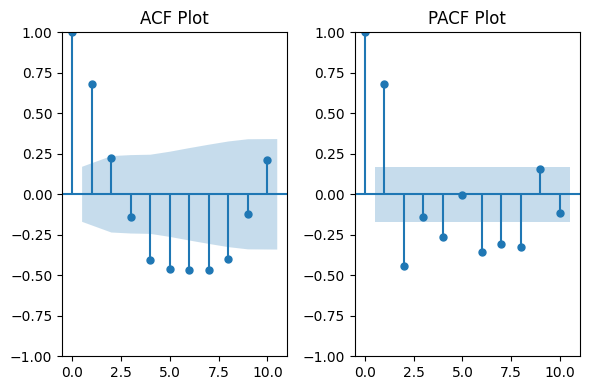

In [ ]:
fig, axes = plt.subplots(1,2, figsize = (6,4))
plot_acf(new_data, lags = 10, ax = axes[0])
axes[0].set_title("ACF Plot")

plot_pacf(new_data, lags = 10, ax = axes[1])
axes[1].set_title("PACF Plot")

plt.tight_layout()
plt.show()

In [ ]:
# p and q

# p -- AR value -- current value depends on previous value
# q -- MA value -- number of past error values used to calculate current
# I -- differencing -- integration

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

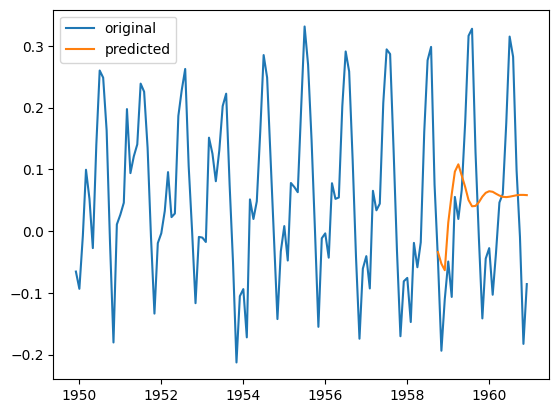

In [ ]:
arima = ARIMA(train, order = (4,1,2))
arima_result = arima.fit()

new_data['predicted_arima']=arima_result.predict(start = len(train), end = len(train)+len(test)-1, dynamic=False)

# if you want to use the previously predicted value as an input to predict the next value then Dynamic = True

plt.plot(new_data['passengers'], label ='original')
plt.plot(new_data['predicted_arima'], label ='predicted')
plt.legend()
plt.show()

In [ ]:
import itertools
from sklearn.metrics import *

p = range(0,10)
d = range(1,2)
q = range(0,8)

pdq = list(itertools.product(p,d,q))
rmse =[]
order1 =[]


for i in pdq:
  model = ARIMA(train, order =i)
  model_fit = model.fit()
  pred = model_fit.predict(start = len(train), end = len(train)+len(test)-1)
  error = np.sqrt(mean_squared_error(test, pred))
  order1.append(i)
  rmse.append(error)

results = pd.DataFrame(index = order1, data = rmse, columns =['RMSE'])

In [ ]:
results.sort_values(by="RMSE", ascending = True)

,RMSE
"(8, 1, 7)",0.060793
"(9, 1, 7)",0.064993
"(9, 1, 3)",0.065136
"(9, 1, 4)",0.065268
"(9, 1, 6)",0.065729
...,...
"(2, 1, 7)",0.149920
"(0, 1, 1)",0.150150
"(2, 1, 0)",0.151556
"(3, 1, 0)",0.151889


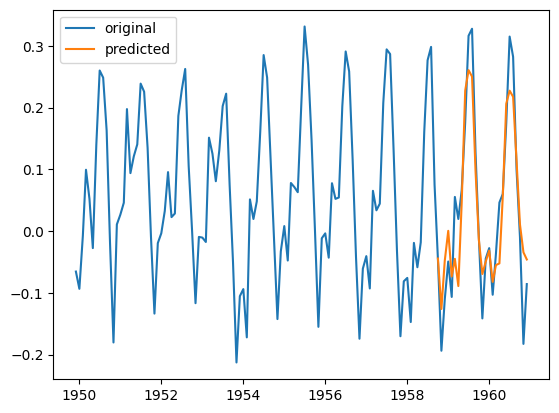

In [ ]:
arima_best = ARIMA(train, order = (8,1,7))
arima_best_result = arima_best.fit()

new_data['best_arima']=arima_best_result.predict(start = len(train), end = len(train)+len(test)-1, dynamic=False)

# if you want to use the previously predicted value as an input to predict the next value then Dynamic = True

plt.plot(new_data['passengers'], label ='original')
plt.plot(new_data['best_arima'], label ='predicted')
plt.legend()
plt.show()

In [ ]:
# Sarima